In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from football_analytics.analyses.passing.features import passing_feature_columns

import os
os.environ["OMP_NUM_THREADS"] = "4"
from sklearn.preprocessing import StandardScaler

In [2]:
df_2018 = pd.read_parquet("../../../artifacts/features/player_level_wc2018.parquet")
df_2022 = pd.read_parquet("../../../artifacts/features/player_level_wc2022.parquet")

df_2018["dataset"] = "WC2018"
df_2022["dataset"] = "WC2022"

df = pd.concat([df_2018, df_2022], ignore_index=True)
df = df[df["player_position"] != "Goalkeeper"]
passing_cols = passing_feature_columns()
passing_df = df[["player_key", "player_position", "player"] + passing_cols]
orig_df = df.copy()
os.environ["OMP_NUM_THREADS"] = "2"

In [3]:
df = passing_df.copy()

df = df.dropna(subset=["player_position"])

In [4]:
FEATURES = [
    'passes_per_90','short_passes_per_90','medium_passes_per_90','long_passes_per_90',
    'crosses_per90','switches_per90','throughballs_per90','cutbacks_per90','backheels_per90',
    'passes_under_pressure_per90','key_passes_per90','assists_per90','pct_passes_under_pressure',
    'avg_pass_length','std_pass_length','pct_short_pass','pct_med_pass','pct_long_pass',
    'pct_ground_pass','pct_low_pass','pct_high_pass','pct_left_foot_pass','pct_right_foot_pass',
    'pct_head_pass','pct_foot_pass','pct_other_pass','pct_keeper_arm_pass',
    'pct_progressive_passes','pct_lateral_passes','pct_defensive_passes',
    'pct_pass_from_def_third','pct_pass_from_mid_third','pct_pass_from_att_third',
    'pct_pass_from_left_channel','pct_pass_from_central_channel','pct_pass_from_right_channel',
    'pct_pass_to_def_third','pct_pass_to_mid_third','pct_pass_to_left_channel',
    'pct_pass_to_central_channel','pct_pass_to_right_channel',
    'pct_passes_final_third','pct_passes_into_box',
    'pct_pass_from_zone_dl','pct_pass_to_zone_dl','pct_pass_from_zone_dc','pct_pass_to_zone_dc',
    'pct_pass_from_zone_dr','pct_pass_to_zone_dr','pct_pass_from_zone_ml','pct_pass_to_zone_ml',
    'pct_pass_from_zone_mc','pct_pass_to_zone_mc','pct_pass_from_zone_mr','pct_pass_to_zone_mr',
    'pct_pass_from_zone_al','pct_pass_to_zone_al','pct_pass_from_zone_ac','pct_pass_to_zone_ac',
    'pct_pass_from_zone_ar','pct_pass_to_zone_ar',
    'pct_pass_def_to_mid','pct_pass_def_to_att','pct_pass_mid_to_att','pct_pass_mid_to_mid',
    'pct_pass_att_to_mid','pct_pass_def_to_def','pct_pass_att_to_att',
    'pct_pass_left_to_centre','pct_pass_left_to_right','pct_pass_right_to_centre',
    'pct_pass_right_to_left','pct_pass_centre_to_left','pct_pass_centre_to_right',
    'pct_pass_wide_to_box','pct_pass_centre_to_box','pct_pass_def_to_box',
    'ttl_passes_F','pct_passes_F','passes_F_per90',
    'ttl_passes_FR','pct_passes_FR','passes_FR_per90',
    'ttl_passes_R','pct_passes_R','passes_R_per90',
    'ttl_passes_BR','pct_passes_BR','passes_BR_per90',
    'ttl_passes_B','pct_passes_B','passes_B_per90',
    'ttl_passes_BL','pct_passes_BL','passes_BL_per90',
    'ttl_passes_L','pct_passes_L','passes_L_per90',
    'ttl_passes_FL','pct_passes_FL','passes_FL_per90',
    'pass_angle_mean_overall','pass_angle_var_overall',
    'pass_angle_mean_def_third','pass_angle_var_def_third',
    'pass_angle_mean_mid_third','pass_angle_var_mid_third',
    'pass_angle_mean_att_third','pass_angle_var_att_third',
    'pass_angle_mean_left_channel','pass_angle_var_left_channel',
    'pass_angle_mean_centre_channel','pass_angle_var_centre_channel',
    'pass_angle_mean_right_channel','pass_angle_var_right_channel'
]


In [5]:
df0 = passing_df.copy()

df1 = df0[
    (df0["has_minutes"] == 1) &
    (df0["has_pass_events"] == 1) &
    (df0["passes_per_90"].fillna(0) > 0) &
    (df0["player_position"].notna())
].copy()

len(df0), len(df1), df1["player_position"].value_counts().head(30)

(1203,
 950,
 player_position
 Left Center Back             91
 Right Center Back            91
 Right Back                   84
 Center Forward               79
 Left Back                    73
 Right Wing                   61
 Left Wing                    60
 Right Center Midfield        57
 Left Center Midfield         56
 Right Defensive Midfield     43
 Center Attacking Midfield    36
 Left Defensive Midfield      35
 Center Defensive Midfield    27
 Right Midfield               27
 Left Midfield                27
 Right Center Forward         25
 Left Center Forward          21
 Center Back                  17
 Right Wing Back              16
 Left Wing Back               14
 Left Attacking Midfield       4
 Center Midfield               3
 Right Attacking Midfield      3
 Name: count, dtype: int64)

In [6]:
X = df1[FEATURES].copy()
X[FEATURES].isna().mean().sort_values(ascending=False).head(15)
X["backheels_per90"] = X["backheels_per90"].fillna(0.0)


In [7]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
Xs = scaler.fit_transform(X)
Xs = pd.DataFrame(Xs, columns=FEATURES, index=df1.index)
Xs.head(10)

,passes_per_90,short_passes_per_90,medium_passes_per_90,long_passes_per_90,crosses_per90,switches_per90,throughballs_per90,cutbacks_per90,backheels_per90,passes_under_pressure_per90,...,pass_angle_mean_mid_third,pass_angle_var_mid_third,pass_angle_mean_att_third,pass_angle_var_att_third,pass_angle_mean_left_channel,pass_angle_var_left_channel,pass_angle_mean_centre_channel,pass_angle_var_centre_channel,pass_angle_mean_right_channel,pass_angle_var_right_channel
0,-0.627386,-0.175537,-0.637076,-0.683500,1.068761,-0.195181,0.0,0.000000,0.000000,0.465205,...,-0.649028,-0.044296,-0.480193,-0.159542,-0.652451,-2.034394,0.605813,-0.705338,-0.266882,0.082908
2,0.558188,0.889960,0.286026,0.527051,-0.077228,0.642161,0.0,0.000000,0.000000,1.898145,...,-0.395924,0.948948,-0.151062,0.414448,-2.198162,0.547231,0.109208,0.444732,0.127343,1.189872
3,-0.149580,0.109663,-0.196884,-0.112758,0.189568,-0.609397,0.0,0.000000,0.000000,1.586412,...,0.293110,0.166184,-0.366643,-0.053300,0.192261,0.014524,0.314958,0.392079,0.310721,0.310452
4,-0.439166,-0.159918,-0.551536,-0.127777,1.927500,0.825047,0.0,0.000000,0.316901,-0.506450,...,1.015235,-0.023467,0.818860,-0.363454,0.732574,-0.509431,1.798147,-1.121509,-0.429098,-0.851970
5,1.230567,0.752261,1.251846,1.451219,-0.344024,0.016382,0.0,0.000000,0.000000,0.131653,...,0.256233,-0.278989,0.118679,-0.526520,-0.221306,0.247753,-0.023961,-0.700349,1.336804,-1.920614
6,-0.458311,0.137735,-0.552489,-0.663735,0.702530,-0.404837,0.0,0.316344,2.530756,0.137497,...,-0.845088,-0.114265,-0.836999,0.726617,0.391094,0.248609,0.047145,0.408300,-0.738363,0.176888
7,0.030244,-0.499704,0.067515,1.008596,-0.344024,-0.082724,0.0,0.000000,0.000000,-0.186193,...,0.314963,-0.581035,0.083132,-1.866465,-0.002093,-0.003049,0.244739,-0.463934,1.379087,-1.337945
8,1.301344,-0.532935,1.113872,4.010453,-0.344024,4.396834,0.0,0.000000,0.000000,0.339476,...,-0.265472,-0.545294,0.006685,-1.866465,-0.400119,-0.774161,-0.383729,-0.591522,0.135296,0.136399
9,0.456516,0.761004,0.807262,-0.755951,-0.344024,-0.609397,0.0,0.000000,0.952381,0.926657,...,0.530302,0.723299,0.993838,0.443023,0.822950,0.773836,0.598564,0.470282,-0.958135,0.130696
10,0.021652,0.106296,-0.027030,0.230351,0.990609,0.386647,0.0,0.000000,0.220049,0.567115,...,-0.765661,0.757757,-0.631889,0.271190,0.134851,0.621402,-1.530614,0.732516,-0.385715,0.036383


In [8]:
from sklearn.decomposition import PCA

pca = PCA()
Xp = pca.fit_transform(Xs)


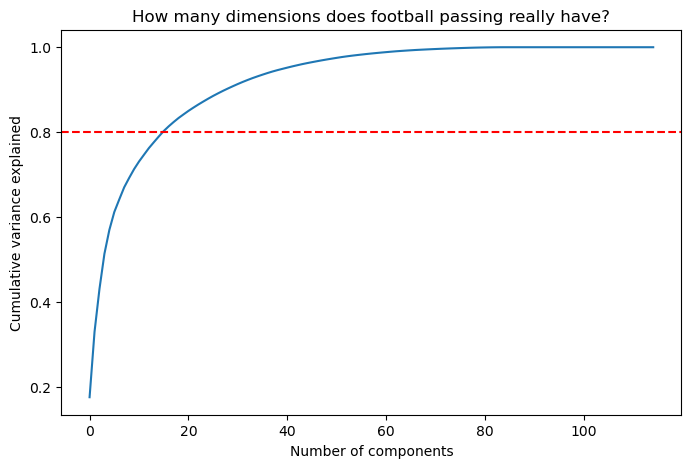

In [9]:
import numpy as np
import matplotlib.pyplot as plt

expl = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(expl)
plt.axhline(0.8, color="red", linestyle="--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance explained")
plt.title("How many dimensions does football passing really have?")
plt.show()


In [10]:
loadings = pd.Series(pca.components_[0], index=FEATURES)
loadings.sort_values(ascending=False).head(10), loadings.sort_values().head(50)


(pct_other_pass             0.355225
 pct_short_pass             0.156024
 pct_pass_from_zone_ac      0.147192
 pct_passes_final_third     0.144202
 pct_pass_from_att_third    0.141868
 pct_pass_att_to_att        0.140855
 pct_passes_B               0.138110
 pct_pass_to_zone_ac        0.133510
 pct_low_pass               0.125689
 pct_passes_into_box        0.123596
 dtype: float64,
 pct_pass_from_def_third         -0.164762
 pct_pass_to_zone_dc             -0.157788
 pct_pass_def_to_def             -0.157193
 pct_pass_from_zone_dc           -0.156722
 avg_pass_length                 -0.154393
 pct_pass_def_to_att             -0.145590
 pct_pass_def_to_mid             -0.144746
 ttl_passes_FL                   -0.143335
 pct_pass_to_def_third           -0.141869
 long_passes_per_90              -0.139563
 medium_passes_per_90            -0.138755
 pct_progressive_passes          -0.137694
 pct_med_pass                    -0.135174
 ttl_passes_FR                   -0.125623
 ttl_passes

In [11]:
loadings2 = pd.Series(pca.components_[1], index=FEATURES)
loadings2.sort_values(ascending=False).head(10), loadings2.sort_values().head(50)

(ttl_passes_BR                 0.210211
 pct_pass_from_zone_dl         0.202733
 passes_BR_per90               0.198626
 pct_pass_to_left_channel      0.195066
 pct_pass_from_left_channel    0.177524
 pct_pass_from_zone_ml         0.171471
 pct_passes_BR                 0.166340
 pct_pass_to_zone_ml           0.163344
 passes_R_per90                0.157354
 ttl_passes_R                  0.154479
 dtype: float64,
 pct_pass_to_right_channel      -2.060829e-01
 passes_BL_per90                -1.900061e-01
 pct_pass_from_zone_dr          -1.887337e-01
 pct_pass_from_right_channel    -1.780576e-01
 pct_pass_from_zone_mr          -1.671252e-01
 pct_passes_BL                  -1.664552e-01
 pct_pass_to_zone_mr            -1.649270e-01
 ttl_passes_BL                  -1.615911e-01
 pct_pass_to_zone_dr            -1.592794e-01
 pct_pass_right_to_centre       -1.564165e-01
 pct_passes_L                   -1.533145e-01
 passes_L_per90                 -1.340252e-01
 pct_right_foot_pass           

In [12]:
loadings3 = pd.Series(pca.components_[2], index=FEATURES)
loadings3.sort_values(ascending=False).head(10), loadings3.sort_values().head(50)

(pct_other_pass             0.479582
 pct_pass_def_to_att        0.182842
 pct_head_pass              0.165974
 pct_pass_from_def_third    0.129485
 pct_pass_from_zone_dc      0.128699
 pct_pass_def_to_mid        0.128065
 pct_pass_def_to_def        0.108049
 pct_pass_to_zone_dc        0.105017
 pct_high_pass              0.100835
 pct_passes_F               0.098641
 dtype: float64,
 short_passes_per_90             -0.223332
 pct_foot_pass                   -0.213041
 ttl_passes_B                    -0.169559
 passes_under_pressure_per90     -0.168787
 passes_B_per90                  -0.168502
 ttl_passes_BR                   -0.157271
 passes_per_90                   -0.154380
 ttl_passes_BL                   -0.150559
 passes_BL_per90                 -0.146926
 ttl_passes_R                    -0.134201
 passes_BR_per90                 -0.131502
 key_passes_per90                -0.131086
 ttl_passes_L                    -0.128872
 crosses_per90                   -0.125536
 passes_R_p

In [13]:
loadings4 = pd.Series(pca.components_[3], index=FEATURES)
loadings4.sort_values(ascending=False).head(10), loadings4.sort_values().head(50)

(pct_other_pass                   0.583485
 ttl_passes_L                     0.176358
 ttl_passes_R                     0.175073
 ttl_passes_FL                    0.158186
 pct_pass_mid_to_mid              0.156155
 pass_angle_var_right_channel     0.155076
 pct_pass_from_zone_mc            0.147760
 pct_pass_to_zone_mc              0.146197
 pass_angle_var_centre_channel    0.139332
 pct_pass_from_central_channel    0.135388
 dtype: float64,
 pct_high_pass                  -0.114703
 pct_pass_def_to_att            -0.109396
 pct_passes_F                   -0.101971
 pct_pass_wide_to_box           -0.101355
 crosses_per90                  -0.096100
 pct_left_foot_pass             -0.093694
 pct_pass_from_zone_dl          -0.081220
 pct_defensive_passes           -0.080768
 std_pass_length                -0.076505
 pct_passes_into_box            -0.074893
 pct_progressive_passes         -0.064828
 pct_long_pass                  -0.061036
 pct_pass_from_zone_al          -0.056832
 pct_pa

In [14]:
pca20 = PCA(n_components=20, random_state=42)
Xp = pca20.fit_transform(Xs)


In [15]:
df_embed = pd.DataFrame(Xp, index=df1.index)
df_embed["player"] = df1["player"]
df_embed["player_position"] = df1["player_position"]
df_embed=df_embed[df_embed["player_position"] != "Goalkeeper"].copy()
df_embed.head(10)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,player,player_position
0,3.050161,-4.555134,-1.325578,-2.667504,-0.305646,-0.077750,-0.232081,0.193897,-0.746467,-1.245236,...,0.106841,-2.531262,-0.751318,0.195512,1.077082,0.303835,0.216882,-1.022386,Ismaïla Sarr,Right Wing
2,-0.737624,-1.920594,-2.332703,1.448847,-1.618386,0.528784,0.054106,-1.111075,2.264255,0.379910,...,1.488563,-0.743277,-0.158008,-0.497267,-0.286306,0.453590,-0.247236,-1.585602,Youri Tielemans,Left Center Midfield
3,0.707569,-1.096771,-0.701224,-0.940818,-1.821298,0.006844,-0.396277,-1.187347,0.672715,1.771171,...,2.570910,-1.963215,-1.543296,0.602851,-0.293643,0.711437,0.627859,-2.298347,Saîf-Eddine Khaoui,Left Center Midfield
4,4.496579,4.579297,-2.464932,-3.914099,1.103830,1.364568,-3.326900,-0.580452,-0.114373,-0.674971,...,-1.074082,-0.820506,1.522811,1.994885,-0.177740,-0.243952,0.571342,-0.450204,Ángel Fabián Di María Hernández,Left Wing
5,-4.277359,4.040778,0.513375,1.078616,-0.599121,-0.793337,1.296596,-3.201902,-1.751095,2.347214,...,-0.203059,-0.458728,0.525489,1.365035,-0.108265,-1.044219,0.985983,1.291312,Presnel Kimpembe,Left Center Back
6,3.716320,-3.012147,-3.007443,-0.599966,-0.889856,0.883912,-0.978873,1.702268,-1.348920,-0.552808,...,-0.152211,-0.520160,0.072246,-0.359225,-0.712007,-0.037253,0.332591,-0.598368,Kylian Mbappé Lottin,Right Wing
7,-4.737568,3.173346,2.966610,-0.728550,-1.197737,0.161263,-0.011188,-0.904356,0.706880,-0.894188,...,-0.412706,0.900429,0.897334,0.528053,-0.544882,-0.044182,1.163107,0.014803,Mathias Jattah-Njie Jørgensen,Left Center Back
8,-6.981679,-3.943675,1.439289,0.857578,0.593306,1.702388,-1.220353,-3.716830,2.194442,0.793873,...,-1.221880,-0.354887,-0.518743,-2.014025,3.275537,0.742767,-1.208409,3.556416,Kamil Glik,Right Center Back
9,-1.036346,1.840168,-1.849680,2.595998,-3.484693,-2.521569,-0.101901,-0.994851,0.148777,2.138149,...,0.014220,-1.191438,1.246673,0.839424,-0.359061,-0.341747,0.403132,-0.788625,Mousa Sidi Yaya Dembélé,Right Center Midfield
10,1.185598,-1.575669,-2.191730,-0.050359,-0.020059,2.831640,-1.217566,0.637206,-0.281098,0.809061,...,-1.008372,0.297417,0.735799,-1.006676,1.377922,-0.192258,0.142341,-0.512093,Christian Dannemann Eriksen,Center Attacking Midfield


In [16]:
import umap

reducer = umap.UMAP(
    n_neighbors=25,
    min_dist=0.12,
    n_components=2,
    metric="cosine",
    random_state=42
)

Xu = reducer.fit_transform(df_embed.iloc[:, :20])

C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [17]:
df_map = pd.DataFrame(Xu, columns=["x", "y"], index=df_embed.index)
df_map["player"] = df_embed["player"]
df_map["player_position"] = df_embed["player_position"]
df_map.head(10)

,x,y,player,player_position
0,5.406233,5.786457,Ismaïla Sarr,Right Wing
2,3.715154,2.695678,Youri Tielemans,Left Center Midfield
3,4.300766,4.858381,Saîf-Eddine Khaoui,Left Center Midfield
4,1.726415,5.009273,Ángel Fabián Di María Hernández,Left Wing
5,4.551640,-0.523404,Presnel Kimpembe,Left Center Back
6,4.581585,5.774673,Kylian Mbappé Lottin,Right Wing
7,5.435817,-0.373788,Mathias Jattah-Njie Jørgensen,Left Center Back
8,7.021975,1.765857,Kamil Glik,Right Center Back
9,3.578234,3.188387,Mousa Sidi Yaya Dembélé,Right Center Midfield
10,4.340172,5.668652,Christian Dannemann Eriksen,Center Attacking Midfield


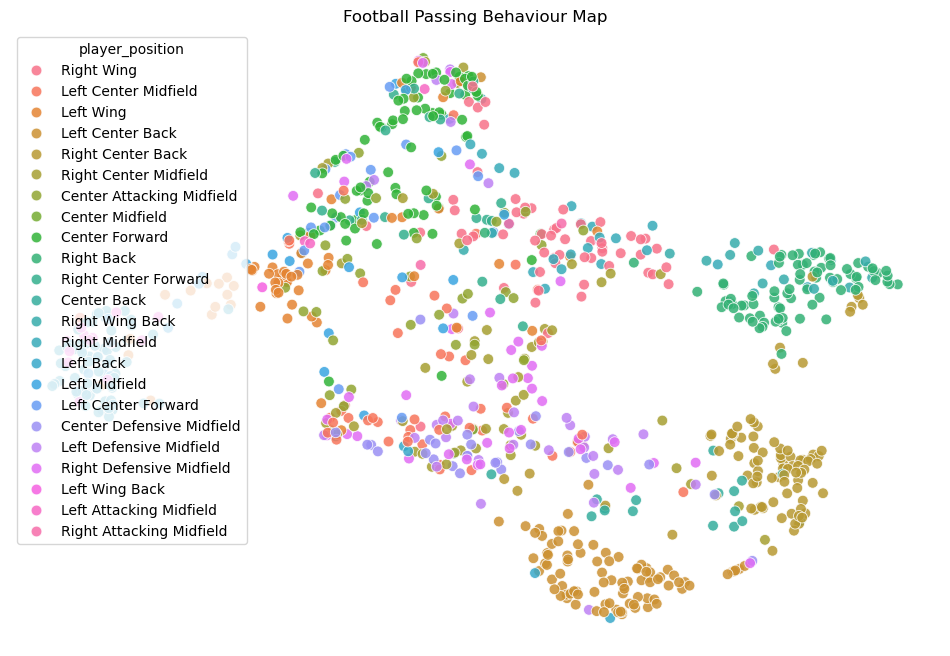

In [18]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df_map, x="x", y="y", hue="player_position", s=60, alpha=0.85)
plt.title("Football Passing Behaviour Map")
plt.axis("off")
plt.show()

In [19]:
import hdbscan

df_outfield = df_embed[df_embed["player_position"] != "Goalkeeper"].copy()


clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=10,
    metric="euclidean"
)

clusters = clusterer.fit_predict(df_outfield.iloc[:, :20])
df_outfield["archetype"] = clusters


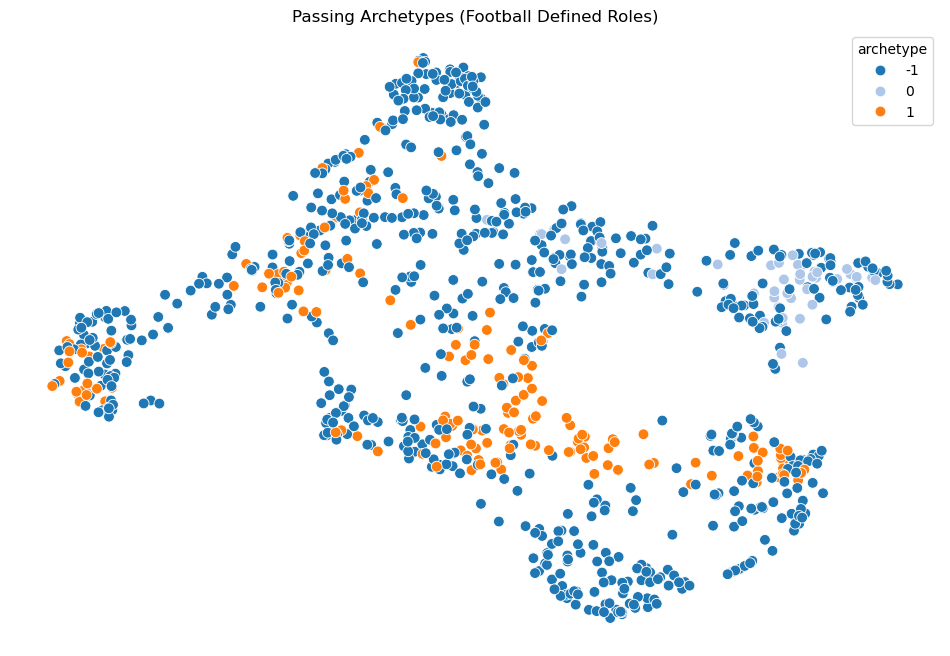

In [20]:
df_map["archetype"] = df_outfield["archetype"]

plt.figure(figsize=(12,8))
sns.scatterplot(data=df_map, x="x", y="y", hue="archetype", palette="tab20", s=60)
plt.title("Passing Archetypes (Football Defined Roles)")
plt.axis("off")
plt.show()


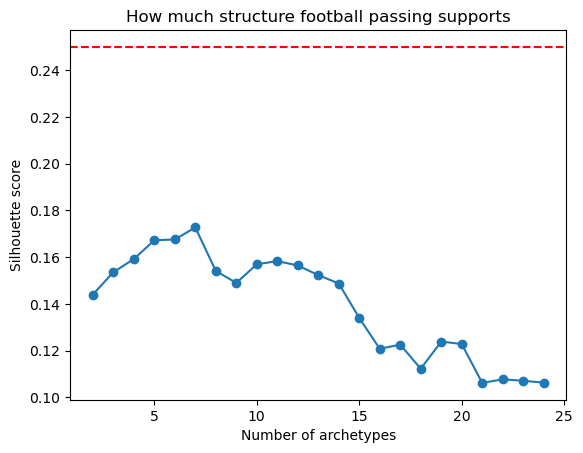

In [21]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
scores = []
Ks = range(2, 25)

for k in Ks:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(df_embed.iloc[:, :20])
    s = silhouette_score(df_embed.iloc[:, :20], labels, metric="euclidean")
    scores.append(s)

plt.plot(Ks, scores, marker="o")
plt.axhline(0.25, color="red", linestyle="--")
plt.xlabel("Number of archetypes")
plt.ylabel("Silhouette score")
plt.title("How much structure football passing supports")
plt.show()



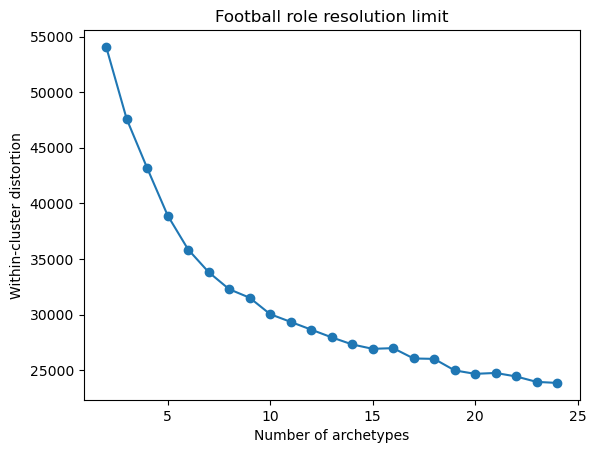

In [22]:
distortions = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_embed.iloc[:, :20])
    distortions.append(km.inertia_)

plt.plot(Ks, distortions, marker="o")
plt.xlabel("Number of archetypes")
plt.ylabel("Within-cluster distortion")
plt.title("Football role resolution limit")
plt.show()


In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=15, random_state=42)
df_embed["role_id"] = kmeans.fit_predict(df_embed.iloc[:, :20])


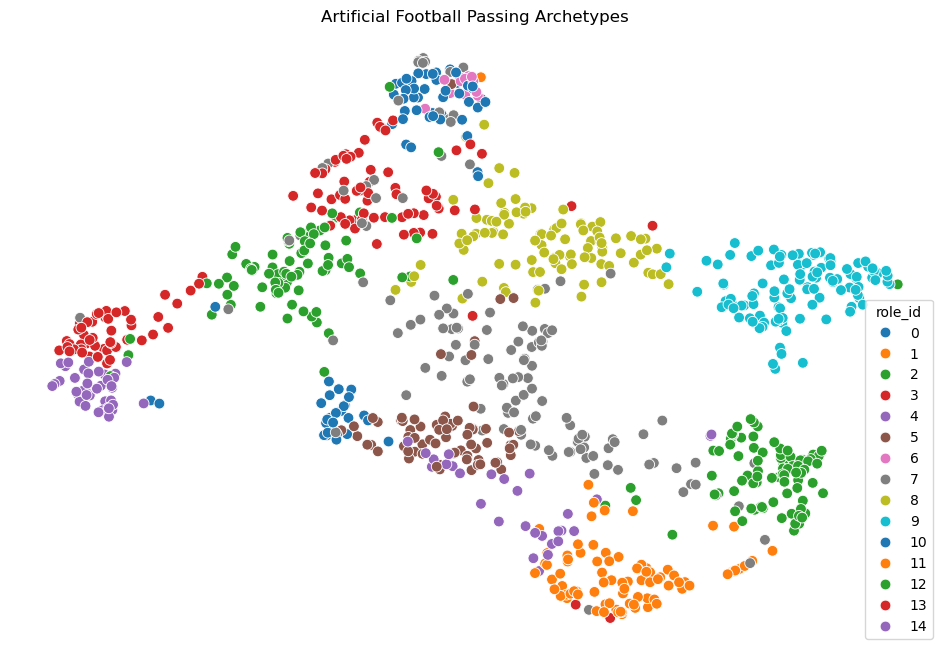

In [24]:
df_map["role_id"] = df_embed["role_id"]

plt.figure(figsize=(12,8))
sns.scatterplot(data=df_map, x="x", y="y", hue="role_id", palette="tab10", s=60)
plt.title("Artificial Football Passing Archetypes")
plt.axis("off")
plt.show()

In [25]:
for name, df in globals().items():
    if isinstance(df, pd.DataFrame) and "role_id" in df.columns:
        print(name, df.shape)



RuntimeError: dictionary changed size during iteration

In [26]:
[c for c in ["df_map", "df_embed", "df_outfield", "df_model", "META"] 
 if c in globals() and isinstance(globals()[c], pd.DataFrame) and "role_id" in globals()[c].columns]


['df_map', 'df_embed']

In [27]:
df_roles = passing_df.merge(df_embed[["player","role_id"]], on="player", how="inner")
role_profiles = df_roles.groupby("role_id")[FEATURES].mean()

In [28]:
global_mean = df_roles[FEATURES].mean()
role_profiles = df_roles.groupby("role_id")[FEATURES].mean()
role_deltas = role_profiles.subtract(global_mean, axis=1)


In [29]:
for r in role_deltas.index:
    print("\nROLE", r)
    print("Top + traits")
    print(role_deltas.loc[r].sort_values(ascending=False).head(10))
    print("\nTop - traits")
    print(role_deltas.loc[r].sort_values().head(10))



ROLE 0
Top + traits
pass_angle_mean_left_channel      21.806248
pass_angle_mean_centre_channel    20.204126
pass_angle_mean_overall           15.645403
pass_angle_mean_att_third         15.254981
pass_angle_mean_mid_third          9.920333
pass_angle_mean_def_third          5.180256
pass_angle_mean_right_channel      4.130287
backheels_per90                    0.238257
pass_angle_var_att_third           0.136507
pct_pass_from_att_third            0.134131
Name: 0, dtype: float64

Top - traits
passes_per_90          -19.922519
ttl_passes_F           -13.893341
ttl_passes_FL          -12.694071
ttl_passes_FR          -11.465248
ttl_passes_R           -11.139434
ttl_passes_L           -10.805290
medium_passes_per_90   -10.140413
ttl_passes_BL           -5.561630
ttl_passes_BR           -5.063363
short_passes_per_90     -4.955655
Name: 0, dtype: float64

ROLE 1
Top + traits
pass_angle_mean_def_third         16.429444
pass_angle_mean_overall           13.785699
pass_angle_mean_att_third   

In [30]:
roles = df_embed[["player", "role_id"]].copy()

df_roles = passing_df.merge(roles, on="player", how="inner")



X_std = pd.DataFrame(
    scaler.transform(df_roles[FEATURES]),
    columns=FEATURES,
    index=df_roles.index,
)
X_std["role_id"] = df_roles["role_id"].values


# Compute standardised role means
role_profiles_std = X_std.groupby("role_id")[FEATURES].mean()

In [31]:
global_std_mean = X_std[FEATURES].mean()
role_deltas_std = role_profiles_std.subtract(global_std_mean, axis=1)


In [32]:
for r in role_deltas_std.index:
    print("\nROLE", r)
    print("Top + traits")
    print(role_deltas_std.loc[r].sort_values(ascending=False).head(10))
    print("\nTop - traits")
    print(role_deltas_std.loc[r].sort_values().head(10))



ROLE 0
Top + traits
pct_other_pass               4.649874
pct_pass_from_zone_ac        0.864219
pct_pass_centre_to_box       0.818560
pct_low_pass                 0.727814
pct_short_pass               0.720848
pct_passes_under_pressure    0.692642
pct_lateral_passes           0.621560
pct_passes_B                 0.548665
pct_head_pass                0.475114
pct_pass_to_zone_ac          0.455874
Name: 0, dtype: float64

Top - traits
pct_foot_pass          -0.988417
passes_per_90          -0.728527
medium_passes_per_90   -0.722877
long_passes_per_90     -0.709097
avg_pass_length        -0.689118
ttl_passes_FL          -0.668109
pct_med_pass           -0.666785
ttl_passes_F           -0.631516
passes_F_per90         -0.629940
passes_FL_per90        -0.612929
Name: 0, dtype: float64

ROLE 1
Top + traits
pct_pass_def_to_att        2.883433
pct_pass_from_zone_dl      2.225559
pct_pass_from_def_third    1.505855
pct_pass_def_to_mid        1.452718
pct_pass_from_zone_dc      1.403465
avg_pa

In [33]:
role_pos_matrix = (
    df_roles
    .groupby(["role_id", "player_position"])
    .size()
    .unstack(fill_value=0)
)

# Convert to percentages per role
role_pos_pct = role_pos_matrix.div(role_pos_matrix.sum(axis=1), axis=0)
role_pos_pct.round(3)


player_position,Center Attacking Midfield,Center Back,Center Defensive Midfield,Center Forward,Center Midfield,Left Attacking Midfield,Left Back,Left Center Back,Left Center Forward,Left Center Midfield,...,Left Wing Back,Right Attacking Midfield,Right Back,Right Center Back,Right Center Forward,Right Center Midfield,Right Defensive Midfield,Right Midfield,Right Wing,Right Wing Back
role_id,,,,,,,,,,,,,,,,,,,,,
0,0.077,0.000,0.015,0.415,0.000,0.015,0.000,0.000,0.046,0.031,...,0.000,0.000,0.000,0.000,0.154,0.000,0.000,0.046,0.077,0.000
1,0.000,0.089,0.022,0.000,0.000,0.000,0.000,0.756,0.000,0.000,...,0.022,0.000,0.000,0.089,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.092,0.008,0.000,0.000,0.000,0.000,0.092,0.000,0.000,...,0.000,0.000,0.025,0.773,0.000,0.000,0.008,0.000,0.000,0.000
3,0.045,0.000,0.000,0.494,0.000,0.011,0.000,0.000,0.112,0.000,...,0.000,0.000,0.000,0.000,0.101,0.022,0.034,0.067,0.056,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.774,0.032,0.000,0.000,...,0.081,0.000,0.016,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.029,0.000,0.171,0.000,0.010,0.000,0.019,0.010,0.010,0.200,...,0.000,0.010,0.038,0.000,0.019,0.162,0.124,0.010,0.019,0.010
6,0.000,0.000,0.000,0.864,0.000,0.000,0.000,0.000,0.045,0.000,...,0.000,0.000,0.000,0.000,0.045,0.000,0.000,0.000,0.000,0.000
7,0.081,0.000,0.056,0.025,0.006,0.000,0.006,0.000,0.000,0.180,...,0.000,0.000,0.012,0.012,0.006,0.217,0.180,0.019,0.037,0.000
8,0.075,0.000,0.007,0.052,0.000,0.007,0.000,0.000,0.015,0.037,...,0.000,0.030,0.015,0.000,0.045,0.045,0.000,0.112,0.425,0.015


In [34]:
role_entropy = -(role_pos_pct * np.log(role_pos_pct + 1e-9)).sum(axis=1)
role_entropy.sort_values()


role_id
6     0.548118
11    0.667830
2     0.812282
4     0.866125
1     0.895849
9     1.171711
13    1.214259
3     1.720350
14    1.746291
12    1.865390
0     1.958022
8     2.076696
7     2.211404
5     2.226989
10    2.253288
dtype: float64

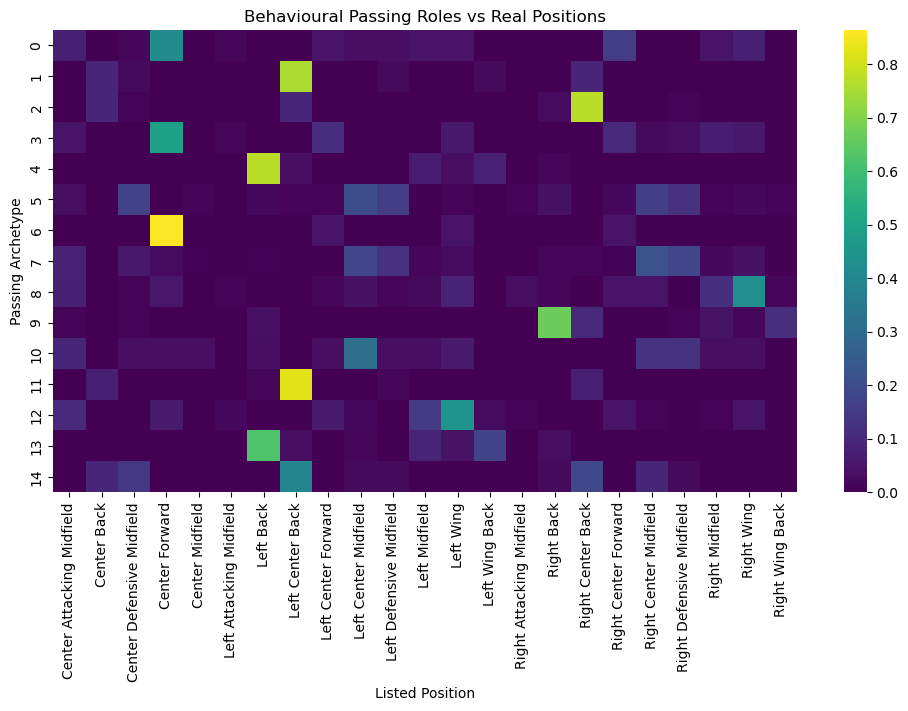

In [35]:
plt.figure(figsize=(12,6))
sns.heatmap(role_pos_pct, cmap="viridis")
plt.title("Behavioural Passing Roles vs Real Positions")
plt.ylabel("Passing Archetype")
plt.xlabel("Listed Position")
plt.show()


In [36]:
from sklearn.cluster import KMeans
import numpy as np


X_umap = Xu
def role_health(X, k):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    labels = km.labels_
    centers = km.cluster_centers_
    sizes = np.bincount(labels)

    # average distance to center per role
    dists = []
    for i in range(k):
        pts = X[labels == i]
        center = centers[i]
        d = np.linalg.norm(pts - center, axis=1).mean()
        dists.append(d)

    return sizes, dists

for k in range(6, 25):
    sizes, dists = role_health(X_umap, k)
    print(f"\n--- k = {k} ---")
    print("min role size:", sizes.min())
    print("avg role spread:", np.mean(dists))



--- k = 6 ---
min role size: 108
avg role spread: 0.9604578

--- k = 7 ---
min role size: 103
avg role spread: 0.83545667

--- k = 8 ---
min role size: 99
avg role spread: 0.74079424

--- k = 9 ---
min role size: 84
avg role spread: 0.6785557

--- k = 10 ---
min role size: 62
avg role spread: 0.6407979

--- k = 11 ---
min role size: 61
avg role spread: 0.607835

--- k = 12 ---
min role size: 56
avg role spread: 0.5782103

--- k = 13 ---
min role size: 42
avg role spread: 0.5510301

--- k = 14 ---
min role size: 44
avg role spread: 0.53168374

--- k = 15 ---
min role size: 34
avg role spread: 0.50582856

--- k = 16 ---
min role size: 40
avg role spread: 0.48839942

--- k = 17 ---
min role size: 34
avg role spread: 0.47807476

--- k = 18 ---
min role size: 27
avg role spread: 0.45939386

--- k = 19 ---
min role size: 31
avg role spread: 0.45000148

--- k = 20 ---
min role size: 22
avg role spread: 0.4409871

--- k = 21 ---
min role size: 23
avg role spread: 0.42980552

--- k = 22 ---
mi

In [37]:
X = passing_df[FEATURES].copy()


In [38]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

embedder = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", RobustScaler()),
    ("pca", PCA(n_components=20, random_state=42)),
])

X20 = embedder.fit_transform(X)


In [39]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def k_sweep_metrics(X, k_values, random_state=42):
    rows = []
    for k in k_values:
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(X)

        # cluster size sanity
        sizes = pd.Series(labels).value_counts()
        min_size = int(sizes.min())

        # metrics
        sil = float(silhouette_score(X, labels))            # higher better
        db  = float(davies_bouldin_score(X, labels))        # lower better
        ch  = float(calinski_harabasz_score(X, labels))     # higher better

        rows.append({
            "k": k,
            "inertia": float(km.inertia_),
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "min_cluster_size": min_size,
        })

    return pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

k_values = range(2, 25)
metrics_df = k_sweep_metrics(X20, k_values)
metrics_df


,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_size
0,2,127348.005478,0.852219,0.445057,443.144609,6
1,3,106379.221979,0.452477,0.812536,383.294463,4
2,4,95389.221812,0.143638,1.582086,330.778762,4
3,5,87373.573381,0.148330,1.519364,298.093523,4
4,6,81982.729939,0.152606,1.496978,269.685729,4
5,7,77157.814817,0.154691,1.457003,251.057106,4
6,8,72790.077086,0.155956,1.425976,238.157214,4
7,9,68907.504780,0.160160,1.339187,228.354333,4
8,10,66203.392968,0.126152,1.491149,216.509874,4
9,11,64072.421695,0.163653,1.317009,205.135338,2
